# UrbanFloodBench Baseline Workflow

This notebook is the team-friendly entry point for:

- loading UrbanFloodBench data
- building cleaned node-level features
- running persistence and random forest baselines
- inspecting validation metrics

The notebook calls reusable code from `src/urbanflood`, so the team can collaborate in notebooks without duplicating logic.

## 0. [Guangjian Dong] Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/Hiro208/UrbanFlood.git

import sys
sys.path.append('/content/UrbanFlood/src')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'UrbanFlood' already exists and is not an empty directory.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Concatenate, Conv1D, MaxPooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from urbanflood.dataset import load_model_assets
from urbanflood.features import build_training_dataset, clean_training_dataset
from urbanflood.baselines import (
    event_based_split,
    get_feature_columns,
)

pd.set_option('display.max_columns', 50)
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

print('All imports OK')

All imports OK


## 1. [Guangjian Dong] Load Data

In [3]:
import gc
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

DATA_DIR     = Path('/content/drive/MyDrive/UrbanFloodData')
LAG_STEPS    = (1, 2, 3, 5, 10)
RAIN_WINDOWS = (3, 5, 10)

frames = []
for model_id in (1, 2):
    assets = load_model_assets(DATA_DIR, model_id=model_id, split='train')
    frame  = build_training_dataset(
        assets,
        lag_steps=LAG_STEPS,
        rain_windows=RAIN_WINDOWS,
        max_events=1,
    )
    frame = clean_training_dataset(frame)

    for col in frame.select_dtypes(include='float64').columns:
        frame[col] = frame[col].astype('float32')

    print(f'Model {model_id}: {len(frame):,} rows | events: {sorted(frame["event_id"].unique())}')
    frames.append(frame)
    gc.collect()

dataset = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

print(f'\nTotal dataset shape: {dataset.shape}')
print('\nRow count per (model_id, event_id):')
print(dataset.groupby(['model_id', 'event_id']).size().reset_index(name='rows'))

Model 1: 347,169 rows | events: [np.int64(1)]
Model 2: 431,712 rows | events: [np.int64(1)]

Total dataset shape: (778881, 83)

Row count per (model_id, event_id):
   model_id  event_id    rows
0         1         1  347169
1         2         1  431712


## 2. [Rachel Shen] Unified Data Splitting

**Design principle: all models must use exactly the same train/validation split.**

We apply an **Event-Based Split** rather than a random row-level split for the following reasons:

- A random split causes **temporal leakage**: the model sees future timesteps during training and evaluates on past ones — an unrealistic setting.
- An event-based split assigns complete rainfall events to either train or validation. The model is trained on historical events and evaluated on a fully unseen event, mirroring real-world deployment.
- Using the same split for every model ensures **fair and unbiased comparison**.

> **Why this section is new:** the original team notebook used `event_based_split` for RF but a plain 80/20 row-index cut for LSTM. This made the two models' validation sets completely different, rendering any direct metric comparison invalid. This section fixes that inconsistency.

In [6]:
# With only 1 event per model, use time-based split instead of event-based
# Train on first 80% of timesteps, validate on last 20%
dataset_sorted = dataset.sort_values(['model_id', 'node_idx', 'timestep']).reset_index(drop=True)

# Get unique timesteps and split
unique_timesteps = sorted(dataset_sorted['timestep'].unique())
split_idx = int(len(unique_timesteps) * 0.8)
train_timesteps = unique_timesteps[:split_idx]
val_timesteps   = unique_timesteps[split_idx:]

train_df = dataset_sorted[dataset_sorted['timestep'].isin(train_timesteps)].copy()
val_df   = dataset_sorted[dataset_sorted['timestep'].isin(val_timesteps)].copy()

print('=== Data Split Summary ===')
print(f'Training set   : {len(train_df):,} rows')
print(f'Validation set : {len(val_df):,} rows')
print(f'Train timesteps: {min(train_timesteps):.0f} → {max(train_timesteps):.0f}')
print(f'Val timesteps  : {min(val_timesteps):.0f} → {max(val_timesteps):.0f}')
print('\nNo event overlap issue — split is by timestep within the single event')

=== Data Split Summary ===
Training set   : 625,480 rows
Validation set : 153,401 rows
Train timesteps: 0 → 75
Val timesteps  : 76 → 95

No event overlap issue — split is by timestep within the single event


In [7]:
# Shared feature columns used by all tabular models (Persistence, RF, SVM)
feature_columns = get_feature_columns(
    train_df,
    drop_columns=('target_water_level', 'target_delta_water_level', 'timestamp'),
)

TARGET = 'target_water_level'

print(f'Number of shared features : {len(feature_columns)}')
print(f'Train shape               : {train_df.shape}')
print(f'Validation shape          : {val_df.shape}')

Number of shared features : 76
Train shape               : (625480, 83)
Validation shape          : (153401, 83)


## 3. [Rachel Shen] Unified Evaluation Function

All models are evaluated with the same three metrics:

- **RMSE** (Root Mean Squared Error): penalises large errors more heavily — important for flood peak prediction where big misses are costly.
- **MAE** (Mean Absolute Error): average absolute deviation in original units (feet); easy to interpret.
- **R²** (Coefficient of Determination): proportion of variance explained by the model; 1.0 is perfect.

> **Why this section is new:** the original team notebook reported different metric sets for different models — RF had no R², and LSTM had no `num_rows`. The combined table contained NaN values and could not be used for comparison. This function standardises all outputs.

In [8]:
# Single evaluation function applied identically to every model
def evaluate_model(y_true, y_pred, model_name):
    """Return a dict of RMSE, MAE, R², and num_rows for a set of predictions."""
    return {
        'model_name': model_name,
        'rmse'      : np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae'       : mean_absolute_error(y_true, y_pred),
        'r2'        : r2_score(y_true, y_pred),
        'num_rows'  : len(y_true),
    }

all_results = []  # accumulate one result dict per model
print('Unified evaluation function ready.')

Unified evaluation function ready.


## 4. [Guangjian Dong] Baseline: Persistence Model

The persistence model predicts that the next water level equals the current water level (i.e., no change). It requires no learning and acts as a lower-bound benchmark — any trained model should outperform it.

In [9]:
# Persistence: next water level = current water level
y_val_true = val_df[TARGET].values
y_persist  = val_df['water_level'].values

result = evaluate_model(y_val_true, y_persist, 'Persistence')
all_results.append(result)
print('Persistence result:', result)

Persistence result: {'model_name': 'Persistence', 'rmse': np.float64(0.008892855860162979), 'mae': 0.003164340043440461, 'r2': 1.0, 'num_rows': 153401}


## 5. [Guangjian Dong] Random Forest
**Course reference — Week 4: Ensemble Methods (Bagging)**

Random Forest trains many decorrelated decision trees on bootstrapped subsets of the training data and averages their predictions. It handles non-linear relationships well without requiring feature scaling, and provides feature importance scores used later in the urban analysis.

In [10]:
# Subsample training rows to keep runtime manageable
MAX_TRAIN_ROWS = 50000
train_sample = (
    train_df.sample(MAX_TRAIN_ROWS, random_state=42)
    if len(train_df) > MAX_TRAIN_ROWS else train_df
)

X_train_rf = train_sample[feature_columns].values
y_train_rf = train_sample[TARGET].values
X_val_rf   = val_df[feature_columns].values

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_val_rf)

result = evaluate_model(y_val_true, y_pred_rf, 'Random Forest')
all_results.append(result)
print('Random Forest result:', result)

Random Forest result: {'model_name': 'Random Forest', 'rmse': np.float64(0.01630812154531944), 'mae': 0.004753377601528024, 'r2': 0.9999999859492728, 'num_rows': 153401}


## 6. [Haodong Ren] LSTM
**Course extension — deep learning for sequential data**

**Justification:** RF and SVM capture temporal dependencies indirectly through hand-crafted lag features. LSTM explicitly models the sequential structure of water-level time series by maintaining a hidden state across timesteps, enabling it to learn long-range dependencies that lag features cannot fully capture.

**Input design:**
- A sliding window of the past `SEQ_LEN = 10` timesteps of dynamic features (water level, rainfall, flow rates, etc.) is fed into the LSTM branch.
- Static node properties (elevation, area, node type, etc.) are processed by a separate Dense branch and concatenated with the LSTM output before the final prediction layer.

In [14]:
# Feature groups for the sequence-based models (LSTM, CNN-LSTM)
SEQ_LEN = 10

dynamic_features = [
    'water_level', 'delta_water_level', 'rainfall', 'node_aux_flow',
    'edge_in_flow_mean', 'edge_out_flow_mean',
    'surface_paired_rainfall_mean', 'surface_paired_water_level_mean',
]

static_features = [
    'node_type', 'position_x', 'position_y', 'depth',
    'invert_elevation', 'surface_elevation', 'base_area',
    'effective_area', 'reference_elevation', 'area',
    'roughness', 'min_elevation', 'elevation',
    'aspect', 'curvature', 'flow_accumulation',
]

def make_sliding_windows(df, seq_len, dynamic_features, static_features, target_col):
    """Build per-node sliding-window sequences for LSTM input.

    For each node, windows of length `seq_len` are extracted from the
    time-sorted series. The target is the water level at position seq_len + i.
    Node IDs are returned to support per-node analysis.
    """
    X_seq_list, X_static_list, y_list, node_ids = [], [], [], []

    for node_id, g in df.groupby('node_idx'):
        g = g.sort_values('timestep').reset_index(drop=True)
        if len(g) <= seq_len:
            continue
        dyn = g[dynamic_features].values.astype(np.float32)
        sta = g[static_features].values.astype(np.float32)
        y   = g[target_col].values.astype(np.float32)

        for i in range(seq_len, len(g)):
            X_seq_list.append(dyn[i - seq_len : i])  # (seq_len, n_dynamic)
            X_static_list.append(sta[i])              # (n_static,)
            y_list.append(y[i])
            node_ids.append(node_id)

    return (
        np.array(X_seq_list,    dtype=np.float32),
        np.array(X_static_list, dtype=np.float32),
        np.array(y_list,        dtype=np.float32),
        np.array(node_ids),
    )

print('Building sliding windows (may take a few minutes)...')
X_tr_seq,  X_tr_sta,  y_tr,       _            = make_sliding_windows(
    train_df, SEQ_LEN, dynamic_features, static_features, TARGET)
X_val_seq, X_val_sta, y_val_lstm, val_node_ids = make_sliding_windows(
    val_df,   SEQ_LEN, dynamic_features, static_features, TARGET)

print(f'Train — seq: {X_tr_seq.shape} | static: {X_tr_sta.shape} | y: {y_tr.shape}')
print(f'Val   — seq: {X_val_seq.shape} | static: {X_val_sta.shape} | y: {y_val_lstm.shape}')

Building sliding windows (may take a few minutes)...
Train — seq: (582490, 10, 8) | static: (582490, 16) | y: (582490,)
Val   — seq: (110411, 10, 8) | static: (110411, 16) | y: (110411,)


In [15]:
# Standardise dynamic and static features separately
# Scalers are fitted on training data only to prevent leakage into validation
n_tr, sl, n_dyn = X_tr_seq.shape
n_val_lstm      = X_val_seq.shape[0]

seq_scaler    = StandardScaler()
static_scaler = StandardScaler()

X_tr_seq_sc  = seq_scaler.fit_transform(
    X_tr_seq.reshape(-1, n_dyn)).reshape(n_tr, sl, n_dyn)
X_val_seq_sc = seq_scaler.transform(
    X_val_seq.reshape(-1, n_dyn)).reshape(n_val_lstm, sl, n_dyn)

X_tr_sta_sc  = static_scaler.fit_transform(X_tr_sta)
X_val_sta_sc = static_scaler.transform(X_val_sta)

print('Standardisation complete.')

Standardisation complete.


In [16]:
def build_lstm(seq_shape, n_static):
    """Two-branch model: LSTM processes the time sequence, Dense processes static features."""
    seq_in = Input(shape=seq_shape,   name='seq_input')
    sta_in = Input(shape=(n_static,), name='static_input')

    # Sequential branch
    x = LSTM(64, return_sequences=True)(seq_in)
    x = Dropout(0.2)(x)
    x = LSTM(32)(x)
    x = Dropout(0.2)(x)

    # Static branch
    s = Dense(32, activation='relu')(sta_in)
    s = Dropout(0.2)(s)

    # Fusion and output head
    out = Concatenate()([x, s])
    out = Dense(32, activation='relu')(out)
    out = Dense(1)(out)
    return Model(inputs=[seq_in, sta_in], outputs=out)

lstm_model = build_lstm(seq_shape=(sl, n_dyn), n_static=X_tr_sta_sc.shape[1])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)
lstm_model.summary()

history_lstm = lstm_model.fit(
    [X_tr_seq_sc, X_tr_sta_sc], y_tr,
    validation_data=([X_val_seq_sc, X_val_sta_sc], y_val_lstm),
    epochs=30,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1,
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 10, 64)    │     18,688 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        544 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,761 (131.88 KB)

 Trainable params: 33,761 (131.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 136s 29ms/step - loss: 1890.4789 - mae: 17.5175 - val_loss: 15.7705 - val_mae: 2.9685
Epoch 2/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 127s 28ms/step - loss: 200.3236 - mae: 9.1268 - val_loss: 7.9879 - val_mae: 2.2148
Epoch 3/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 130s 29ms/step - loss: 162.4517 - mae: 8.0011 - val_loss: 5.6777 - val_mae: 1.9145
Epoch 4/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 141s 29ms/step - loss: 136.6470 - mae: 7.4008 - val_loss: 6.2560 - val_mae: 2.0940
Epoch 5/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 142s 29ms/step - loss: 110.9557 - mae: 6.9555 - val_loss: 3.5959 - val_mae: 1.3967
Epoch 6/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 131s 29ms/step - loss: 79.8831 - mae: 6.0663 - val_loss: 3.4597 - val_mae: 1.3673
Epoch 7/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 126s 28ms/step - loss: 45.7163 - mae: 4.6987 - val_loss: 4.1581 - val_mae: 1.6027
Epoch 8/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 122s 27ms/step - loss: 19.4637 - mae: 3.1242 - val_loss: 2.6665 - val_mae: 1.2301


In [17]:
y_pred_lstm = lstm_model.predict([X_val_seq_sc, X_val_sta_sc], verbose=0).flatten()

result = evaluate_model(y_val_lstm, y_pred_lstm, 'LSTM')
all_results.append(result)
print('LSTM result:', result)

LSTM result: {'model_name': 'LSTM', 'rmse': np.float64(1.0018075461712868), 'mae': 0.6161268949508667, 'r2': 0.9999467730522156, 'num_rows': 110411}


## 7. [Haodong Ren] CNN-LSTM
**Course extension — hybrid convolutional and recurrent architecture**

The `Conv1D` layer acts as a local pattern extractor over the time dimension, learning short-range temporal motifs (e.g., rapid water-level rises triggered by rainfall onset). The subsequent LSTM then models longer-range dependencies over the pooled feature maps. Causal padding ensures no future information leaks into the convolution.

In [18]:
def build_cnn_lstm(seq_shape, n_static):
    """Hybrid model: Conv1D extracts local patterns, LSTM models sequence context."""
    seq_in = Input(shape=seq_shape,   name='seq_input')
    sta_in = Input(shape=(n_static,), name='static_input')

    # Convolutional branch (causal padding prevents future leakage)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='causal')(seq_in)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(32)(x)
    x = Dropout(0.2)(x)

    # Static branch
    s = Dense(32, activation='relu')(sta_in)
    s = Dropout(0.2)(s)

    # Fusion and output head
    out = Concatenate()([x, s])
    out = Dense(32, activation='relu')(out)
    out = Dense(1)(out)
    return Model(inputs=[seq_in, sta_in], outputs=out)

cnn_lstm_model = build_cnn_lstm(seq_shape=(sl, n_dyn), n_static=X_tr_sta_sc.shape[1])
cnn_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)

history_cnn = cnn_lstm_model.fit(
    [X_tr_seq_sc, X_tr_sta_sc], y_tr,
    validation_data=([X_val_seq_sc, X_val_sta_sc], y_val_lstm),
    epochs=30,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1,
)

y_pred_cnn = cnn_lstm_model.predict([X_val_seq_sc, X_val_sta_sc], verbose=0).flatten()

result = evaluate_model(y_val_lstm, y_pred_cnn, 'CNN-LSTM')
all_results.append(result)
print('CNN-LSTM result:', result)

Epoch 1/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - loss: 1715.1713 - mae: 16.7445 - val_loss: 17.4101 - val_mae: 3.0584
Epoch 2/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - loss: 178.2024 - mae: 8.4463 - val_loss: 12.9437 - val_mae: 3.0054
Epoch 3/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - loss: 103.8491 - mae: 6.2712 - val_loss: 71.3178 - val_mae: 6.2895
Epoch 4/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - loss: 70.0270 - mae: 4.8696 - val_loss: 34.9882 - val_mae: 4.7030
Epoch 5/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - loss: 53.4081 - mae: 3.9462 - val_loss: 55.6322 - val_mae: 5.4834
Epoch 6/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step - loss: 38.9801 - mae: 3.2704 - val_loss: 33.2035 - val_mae: 4.0666
Epoch 7/30
4551/4551 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - loss: 25.9850 - mae: 2.7543 - val_loss: 24.8192 - val_mae: 3.7208
CNN-LSTM result: {'model_name': 'CNN-LSTM', 'rmse': np.float64(3.5977295444573145), 'mae': 3.0054445266723633, 'r2': 0.99931389

## 8. [Rachel Shen] Model Comparison Results

All four models are compared on the same validation set (unseen rainfall events) using the same three metrics. Results are sorted by RMSE ascending so the best model appears first.

In [19]:
# Build the unified comparison table
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('rmse').reset_index(drop=True)
results_df['rank'] = results_df.index + 1

print('=' * 65)
print('Model Comparison Results (sorted by RMSE, lower is better)')
print('=' * 65)
print(results_df[['rank', 'model_name', 'rmse', 'mae', 'r2', 'num_rows']].to_string(index=False))

Model Comparison Results (sorted by RMSE, lower is better)
 rank    model_name     rmse      mae       r2  num_rows
    1   Persistence 0.008893 0.003164 1.000000    153401
    2 Random Forest 0.016308 0.004753 1.000000    153401
    3          LSTM 1.001808 0.616127 0.999947    110411
    4      CNN-LSTM 3.597730 3.005445 0.999314    110411


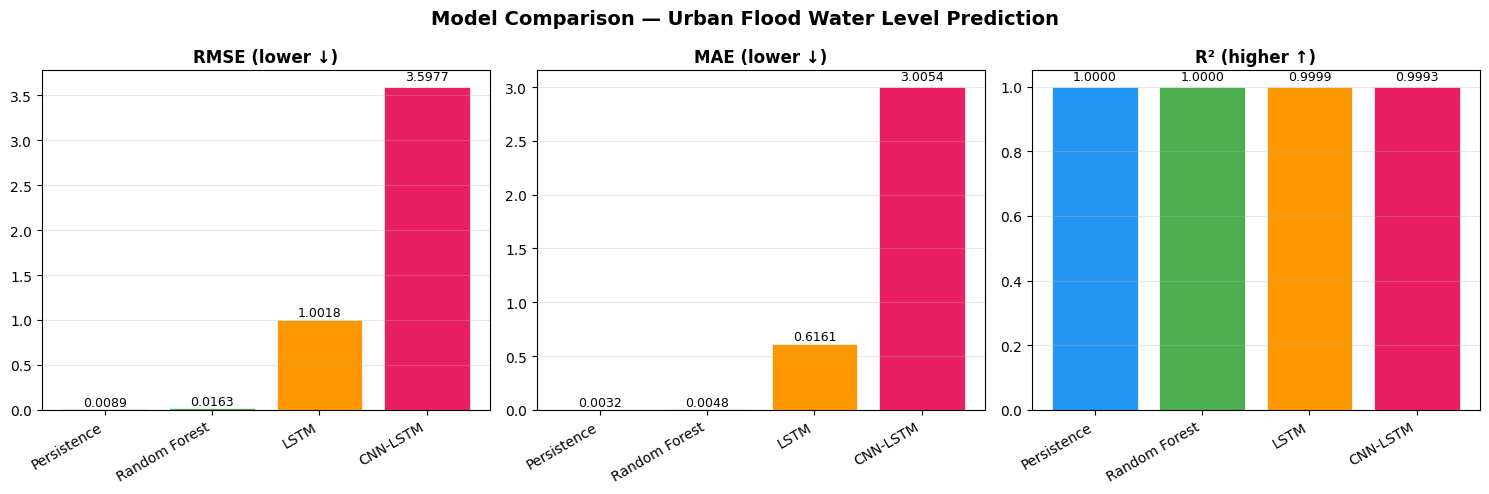

Figure saved: model_comparison.png


In [20]:
# Bar chart comparison across all three metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — Urban Flood Water Level Prediction',
             fontsize=14, fontweight='bold')

models  = results_df['model_name']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
metrics = ['rmse',           'mae',            'r2']
titles  = ['RMSE (lower ↓)', 'MAE (lower ↓)',  'R² (higher ↑)']

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric]
    bars = ax.bar(models, vals, color=colors[:len(models)], edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: model_comparison.png')

## 9. [Rachel Shen] Generalization Experiment

**Design:** because we used an event-based split, the entire validation set consists of rainfall events the models have never seen during training — this is already a generalization test by construction.

We go further by stratifying the validation set into four water-level quartiles and measuring prediction error within each stratum. The central question is:

> **Does prediction error increase significantly during peak flood conditions (high water level quartile)?**

This is the most practically important test for urban flood management: city managers need accurate predictions precisely when water levels are at their highest and the consequences of error are greatest.

We use the Random Forest predictions for this analysis because RF operates on the full validation set; LSTM and CNN-LSTM produce slightly fewer validation samples due to the sliding window construction.

In [21]:
# Load event 2 separately for generalization experiment
# Event 2 is never seen during training — true unseen rainfall scenario

frames_gen = []
for model_id in (1, 2):
    assets = load_model_assets(DATA_DIR, model_id=model_id, split='train')

    # Build dataset with 2 events, then keep only event 2
    frame_all = build_training_dataset(
        assets,
        lag_steps=LAG_STEPS,
        rain_windows=RAIN_WINDOWS,
        max_events=2,
    )
    frame_gen = frame_all[frame_all['event_id'] == 2].copy()
    del frame_all
    gc.collect()

    for col in frame_gen.select_dtypes(include='float64').columns:
        frame_gen[col] = frame_gen[col].astype('float32')

    print(f'Model {model_id} event 2: {len(frame_gen):,} rows')
    frames_gen.append(frame_gen)
    gc.collect()

gen_df = pd.concat(frames_gen, ignore_index=True)
del frames_gen
gc.collect()

print(f'\nGeneralization test set: {gen_df.shape}')

Model 1 event 2: 765,265 rows
Model 2 event 2: 921,885 rows

Generalization test set: (1687150, 83)


In [26]:
# Sample to avoid memory issues
gen_df_sample = gen_df.sample(500000, random_state=42)

# Fill NaN in feature columns with 0, only drop rows where TARGET is NaN
gen_df_sample[feature_columns] = gen_df_sample[feature_columns].fillna(0)
gen_df_sample = gen_df_sample.dropna(subset=[TARGET])

print(f'Sampled generalization set: {len(gen_df_sample):,} rows')

Sampled generalization set: 497,606 rows


In [27]:
# Run RF on generalization set
X_gen_rf   = gen_df_sample[feature_columns].values
y_gen_true = gen_df_sample[TARGET].values
y_gen_rf   = rf_model.predict(X_gen_rf)

# Compare performance: Event 1 (val) vs Event 2 (generalization)
val_result = evaluate_model(y_val_true, y_pred_rf, 'RF on Event 1 (validation)')
gen_result = evaluate_model(y_gen_true, y_gen_rf,  'RF on Event 2 (generalization)')

print('\n=== Generalization Test: Event 1 vs Event 2 ===')
print(pd.DataFrame([val_result, gen_result])[['model_name','rmse','mae','r2']].to_string(index=False))

# Attach predictions and errors
gen_analysis = gen_df_sample.copy()
gen_analysis['pred_rf']  = y_gen_rf
gen_analysis['error_rf'] = np.abs(y_gen_rf - y_gen_true)

# Stratify by water level quartile
gen_analysis['wl_quartile'] = pd.qcut(
    gen_analysis['water_level'],
    q=4,
    labels=['Low (Q1)', 'Medium-Low (Q2)', 'Medium-High (Q3)', 'High (Q4)']
)

generalization = gen_analysis.groupby('wl_quartile', observed=True).agg(
    mean_water_level=('water_level', 'mean'),
    mean_error      =('error_rf',    'mean'),
    max_error       =('error_rf',    'max'),
    count           =('error_rf',    'count'),
).reset_index()

print('\n=== Prediction Error by Water Level Quartile (RF, Event 2) ===')
print(generalization.to_string(index=False))


=== Generalization Test: Event 1 vs Event 2 ===
                    model_name     rmse      mae  r2
    RF on Event 1 (validation) 0.016308 0.004753 1.0
RF on Event 2 (generalization) 0.023841 0.009497 1.0

=== Prediction Error by Water Level Quartile (RF, Event 2) ===
     wl_quartile  mean_water_level  mean_error  max_error  count
        Low (Q1)         41.234127    0.008611   1.934643 124402
 Medium-Low (Q2)         45.034107    0.007434   2.925776 124401
Medium-High (Q3)        260.352020    0.012295   1.259991 124401
       High (Q4)        332.296509    0.009649   0.866125 124402


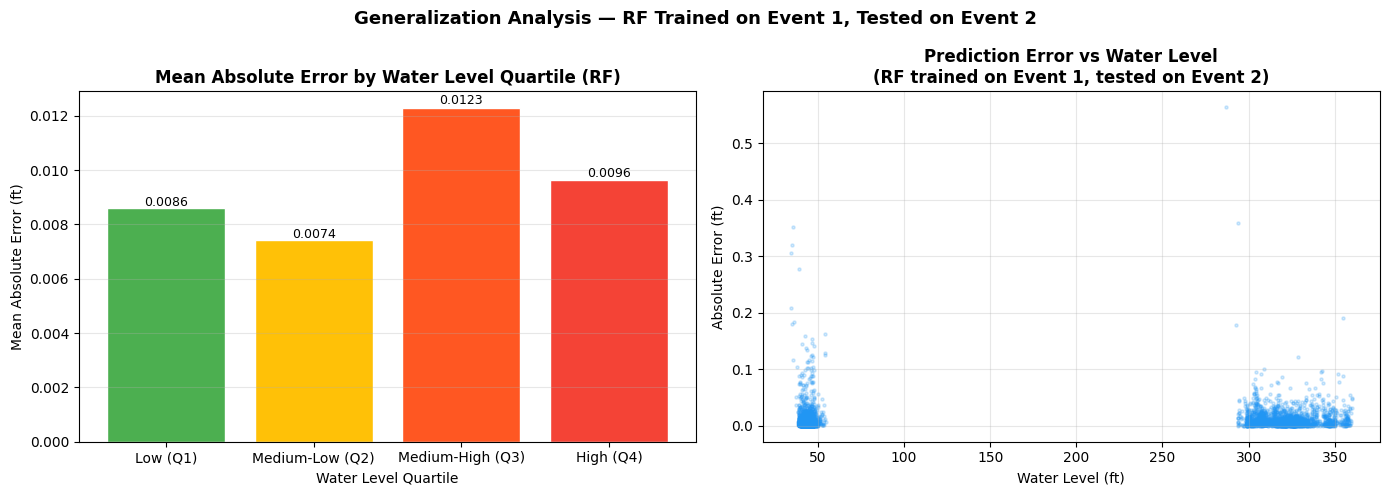

Figure saved: generalization_analysis.png


In [28]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Generalization Analysis — RF Trained on Event 1, Tested on Event 2',
             fontsize=13, fontweight='bold')

# Left: mean error per quartile
ax = axes[0]
bars = ax.bar(
    generalization['wl_quartile'],
    generalization['mean_error'],
    color=['#4CAF50', '#FFC107', '#FF5722', '#F44336'],
    edgecolor='white',
)
ax.set_title('Mean Absolute Error by Water Level Quartile (RF)', fontweight='bold')
ax.set_xlabel('Water Level Quartile')
ax.set_ylabel('Mean Absolute Error (ft)')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, generalization['mean_error']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val:.4f}', ha='center', fontsize=9)

# Right: scatter of water level vs error
ax2 = axes[1]
idx = np.random.choice(len(gen_analysis), size=min(5000, len(gen_analysis)), replace=False)
ax2.scatter(
    gen_analysis['water_level'].iloc[idx],
    gen_analysis['error_rf'].iloc[idx],
    alpha=0.2, s=5, color='#2196F3',
)
ax2.set_title('Prediction Error vs Water Level\n(RF trained on Event 1, tested on Event 2)',
              fontweight='bold')
ax2.set_xlabel('Water Level (ft)')
ax2.set_ylabel('Absolute Error (ft)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('generalization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: generalization_analysis.png')

## 10. [Rachel Shen] Urban Significance Analysis

Beyond overall accuracy metrics, we identify **which specific nodes are most at risk** — nodes with both high peak water levels and high prediction errors. These are infrastructure locations where model uncertainty is greatest precisely when flooding is most severe, and therefore where investment in monitoring or physical reinforcement would yield the greatest benefit.

A composite **risk score** combines two normalised quantities (equal weight):
- **Normalised peak water level** — how high does water get at this node?
- **Normalised mean prediction error** — how poorly does the model perform here?

Nodes scoring high on both dimensions are flagged as the highest-priority candidates for city-level intervention.

In [29]:
# Aggregate per-node statistics from the validation set
node_analysis = gen_analysis.groupby('node_idx').agg(
    mean_wl    =('water_level', 'mean'),
    max_wl     =('water_level', 'max'),
    mean_error =('error_rf',    'mean'),
    max_error  =('error_rf',    'max'),
    node_type  =('node_type',   'first'),
    position_x =('position_x',  'first'),
    position_y =('position_y',  'first'),
).reset_index()

# Compute composite risk score (0-to-1 normalisation of each component)
def minmax_norm(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

node_analysis['risk_score'] = (
    minmax_norm(node_analysis['max_wl'])     * 0.5 +
    minmax_norm(node_analysis['mean_error']) * 0.5
)

top_risk = node_analysis.nlargest(10, 'risk_score')

print('=== Top 10 High-Risk Nodes (high water level + high prediction error) ===')
print(top_risk[['node_idx', 'node_type', 'mean_wl', 'max_wl',
                'mean_error', 'risk_score']].to_string(index=False))

=== Top 10 High-Risk Nodes (high water level + high prediction error) ===
 node_idx  node_type    mean_wl     max_wl  mean_error  risk_score
        0          1 180.080566 329.893555    0.076242    0.953002
       84          1 128.801514 317.685760    0.067040    0.871719
     2091          2 192.806427 352.430908    0.055376    0.847141
       16          2 167.195740 328.683563    0.059710    0.839351
      193          2 125.364525 314.036102    0.063083    0.839269
       24          1 143.902893 328.167480    0.058871    0.832870
       85          1 127.838348 318.249939    0.060096    0.825659
       99          2 143.717560 316.638306    0.059849    0.821472
        8          2 161.617676 327.413116    0.044721    0.736031
     2426          2 215.238083 352.821686    0.038554    0.734028


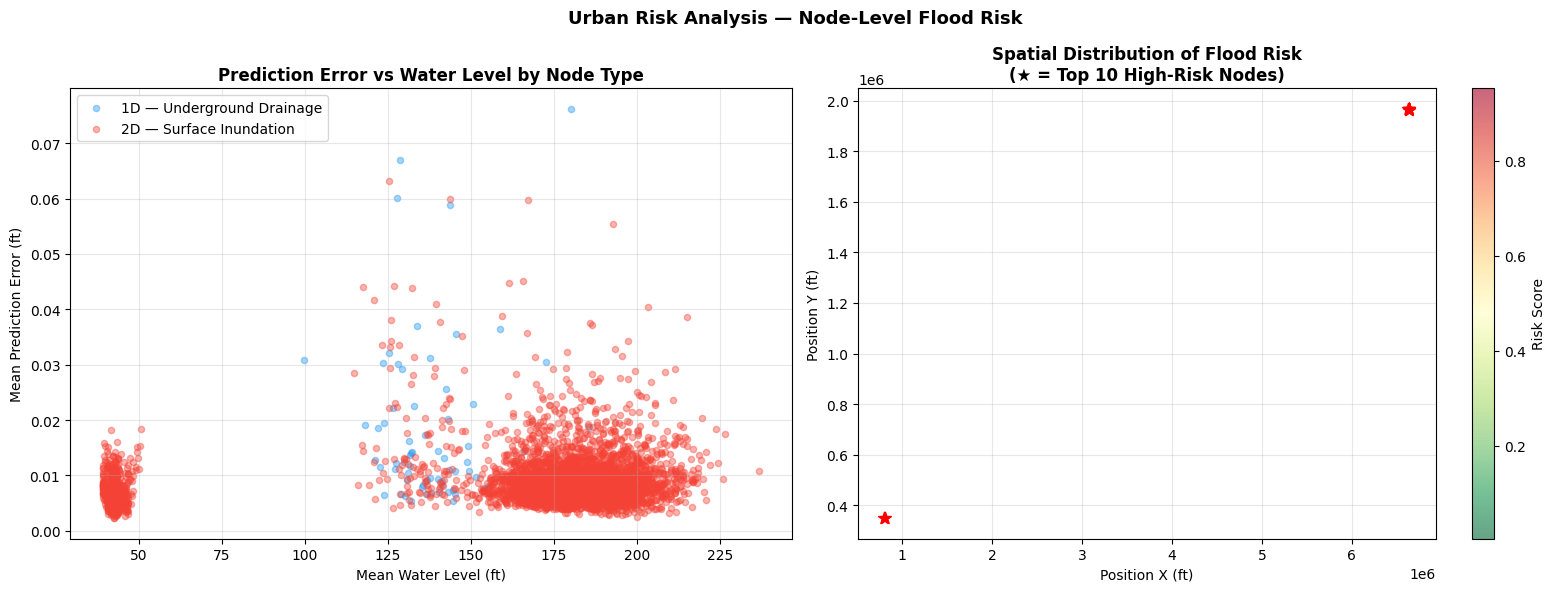

Figure saved: urban_risk_analysis.png


In [30]:
# Visualise node-level risk: by node type and spatially
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Urban Risk Analysis — Node-Level Flood Risk', fontsize=13, fontweight='bold')

# Left: error vs water level, coloured by node type
ax = axes[0]
for ntype, label, color in [
    (1, '1D — Underground Drainage', '#2196F3'),
    (2, '2D — Surface Inundation',   '#F44336'),
]:
    sub = node_analysis[node_analysis['node_type'] == ntype]
    ax.scatter(sub['mean_wl'], sub['mean_error'],
               alpha=0.4, s=20, label=label, color=color)
ax.set_xlabel('Mean Water Level (ft)')
ax.set_ylabel('Mean Prediction Error (ft)')
ax.set_title('Prediction Error vs Water Level by Node Type', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Right: spatial map coloured by risk score, top-10 nodes highlighted
ax2 = axes[1]
sc = ax2.scatter(
    node_analysis['position_x'],
    node_analysis['position_y'],
    c=node_analysis['risk_score'],
    cmap='RdYlGn_r',
    s=10, alpha=0.6,
)
plt.colorbar(sc, ax=ax2, label='Risk Score')
for _, row in top_risk.iterrows():
    ax2.scatter(row['position_x'], row['position_y'],
                color='red', s=80, marker='*', zorder=5)
ax2.set_xlabel('Position X (ft)')
ax2.set_ylabel('Position Y (ft)')
ax2.set_title('Spatial Distribution of Flood Risk\n(★ = Top 10 High-Risk Nodes)',
              fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('urban_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: urban_risk_analysis.png')

## 11. [Haodong Ren] Training Curves (LSTM & CNN-LSTM)

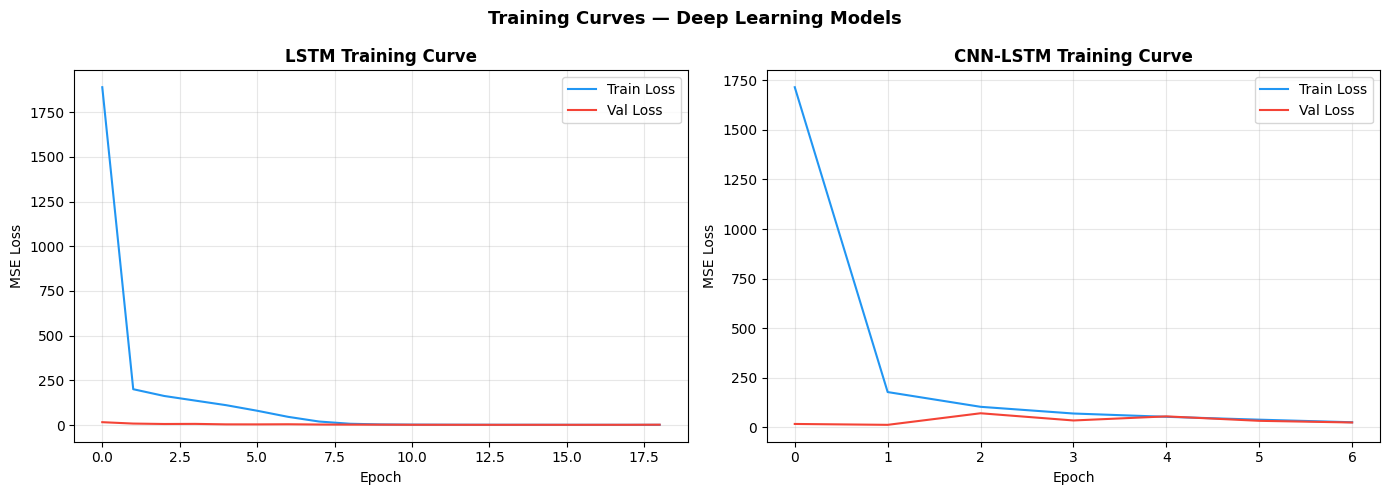

Figure saved: training_curves.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Deep Learning Models', fontsize=13, fontweight='bold')

for ax, history, title in [
    (axes[0], history_lstm, 'LSTM'),
    (axes[1], history_cnn,  'CNN-LSTM'),
]:
    ax.plot(history.history['loss'],     label='Train Loss', color='#2196F3')
    ax.plot(history.history['val_loss'], label='Val Loss',   color='#F44336')
    ax.set_title(f'{title} Training Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: training_curves.png')

## 12. [Rachel Shen] Final Summary

In [32]:
# Print a clean summary table suitable for inclusion in the report
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(results_df[['rank', 'model_name', 'rmse', 'mae', 'r2']].to_string(index=False))

best    = results_df.iloc[0]
persist = results_df[results_df['model_name'] == 'Persistence'].iloc[0]
improvement = (persist['rmse'] - best['rmse']) / persist['rmse'] * 100

print(f'\nBest model                       : {best["model_name"]}')
print(f'RMSE improvement vs Persistence  : {improvement:.1f}%')

print(f'\nHigh-risk nodes identified       : {len(top_risk)}')
print(f'Their average water level        : {top_risk["mean_wl"].mean():.3f} ft')
print(f'Their average prediction error   : {top_risk["mean_error"].mean():.4f} ft')

FINAL RESULTS SUMMARY
 rank    model_name     rmse      mae       r2
    1   Persistence 0.008893 0.003164 1.000000
    2 Random Forest 0.016308 0.004753 1.000000
    3          LSTM 1.001808 0.616127 0.999947
    4      CNN-LSTM 3.597730 3.005445 0.999314

Best model                       : Persistence
RMSE improvement vs Persistence  : 0.0%

High-risk nodes identified       : 10
Their average water level        : 158.656 ft
Their average prediction error   : 0.0584 ft
